In [16]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request
from sklearn.decomposition import PCA

import pandas as pd


In [15]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x7f4f75f76cd0>)

In [17]:
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [12]:
df_stars['Star type'][np.isnan(df_stars['Star type'])]

Series([], Name: Star type, dtype: int64)

In [37]:
X = np.array([df_stars['Temperature (K)'],df_stars['Absolute magnitude(Mv)'], df_stars['Radius(R/Ro)'], df_stars['Luminosity(L/Lo)']])
X = X.T
X

array([[ 3.06800e+03,  1.61200e+01,  1.70000e-01,  2.40000e-03],
       [ 3.04200e+03,  1.66000e+01,  1.54200e-01,  5.00000e-04],
       [ 2.60000e+03,  1.87000e+01,  1.02000e-01,  3.00000e-04],
       [ 2.80000e+03,  1.66500e+01,  1.60000e-01,  2.00000e-04],
       [ 1.93900e+03,  2.00600e+01,  1.03000e-01,  1.38000e-04],
       [ 2.84000e+03,  1.69800e+01,  1.10000e-01,  6.50000e-04],
       [ 2.63700e+03,  1.72200e+01,  1.27000e-01,  7.30000e-04],
       [ 2.60000e+03,  1.74000e+01,  9.60000e-02,  4.00000e-04],
       [ 2.65000e+03,  1.74500e+01,  1.10000e-01,  6.90000e-04],
       [ 2.70000e+03,  1.60500e+01,  1.30000e-01,  1.80000e-04],
       [ 3.60000e+03,  1.06900e+01,  5.10000e-01,  2.90000e-03],
       [ 3.12900e+03,  1.17900e+01,  3.76100e-01,  1.22000e-02],
       [ 3.13400e+03,  1.32100e+01,  1.96000e-01,  4.00000e-04],
       [ 3.62800e+03,  1.04800e+01,  3.93000e-01,  5.50000e-03],
       [ 2.65000e+03,  1.17820e+01,  1.40000e-01,  6.00000e-04],
       [ 3.34000e+03,  1.

In [69]:
n_comp = 2
pca = PCA(n_components=n_comp) # n_components can be optionally set
pca.fit(X) 


eigenvalues = pca.transform(X) # compute the subspace projection of X, 4 eigenvalues for each of the 100 samples
mean = pca.mean_ # length 10 mean of the data
eigenvectors = pca.components_ # 4x10 matrix of components, multiply each by respective eigenvalue to reconstruct

# Reconstruction of object1
# Xreconstruct[0] = mean + eigenvectors*eigenvalues[0]

print(eigenvalues.shape)
print(eigenvectors.shape)

(240, 2)
(2, 4)


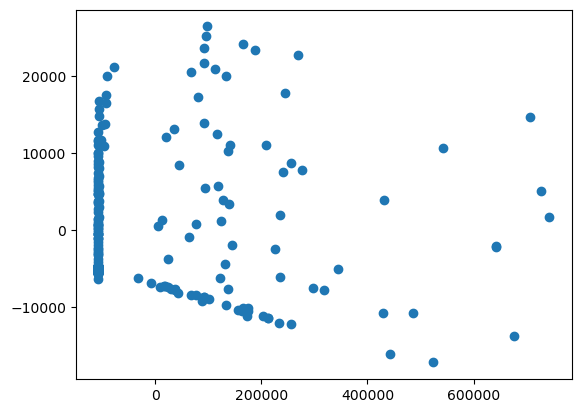

In [74]:
plt.scatter(eigenvalues[:,0],eigenvalues[:,1]) #i need to standardise the data: ... StandardScaler

In [75]:

pca_comp = np.vstack([mean, pca.components_]) # Add the mean to the components
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Expained fractional variance of data encapsulated in the eigenvalues: [0.99760631 0.0023879 ]


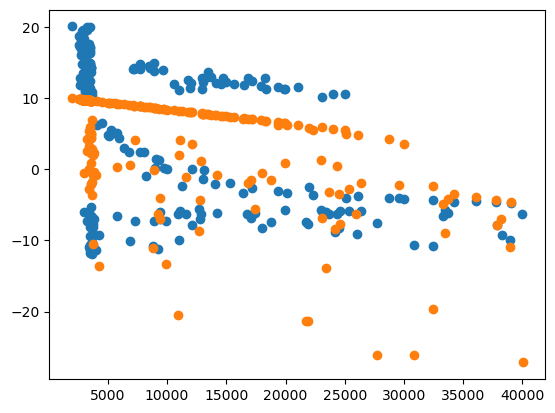

In [76]:
X_recon = pca.inverse_transform(eigenvalues)
X_recon.T
plt.scatter(X.T[0],X.T[1])
plt.scatter(X_recon.T[0],X_recon.T[1])